# Lab 6

You are tasked with evaluating card counting strategies for black jack. In order to do so, you will use object oriented programming to create a playable casino style black jack game where a computer dealer plays against $n$ computer players and possibily one human player. If you don't know the rules of blackjack or card counting, please google it. 

A few requirements:
* The game should utilize multiple 52-card decks. Typically the game is played with 6 decks.
* Players should have chips.
* Dealer's actions are predefined by rules of the game (typically hit on 16). 
* The players should be aware of all shown cards so that they can count cards.
* Each player could have a different strategy.
* The system should allow you to play large numbers of games, study the outcomes, and compare average winnings per hand rate for different strategies.

1. Begin by creating a classes to represent cards and decks. The deck should support more than one 52-card set. The deck should allow you to shuffle and draw cards. Include a "plastic" card, placed randomly in the deck. Later, when the plastic card is dealt, shuffle the cards before the next deal.

In [1]:
import sys
!{sys.executable} -m pip install matplotlib numpy

In [3]:
import random
from typing import Optional

Suits = ("Hearts", "Diamonds", "Spades", "Clubs")
Ranks = ("A", "2", "3", "4", "5", "6", "7", "8", "9", "10", "J", "Q", "K")

Rank_values: dict[str, int] = {
    "A": 11, "2": 2, "3": 3, "4": 4, "5": 5,
    "6": 6,  "7": 7, "8": 8, "9": 9, "10": 10,
    "J": 10, "Q": 10, "K": 10,
}

class Card:
    def __init__(self, rank: str, suit: str, face_up: bool = True):
        if rank not in Ranks:
            raise ValueError(f"Invalid rank: {rank!r}")
        if suit not in Suits:
            raise ValueError(f"Invalid suit: {suit!r}")
        self.rank = rank
        self.suit = suit
        self.face_up = face_up

    @property
    def value(self) -> int:
        return Rank_values[self.rank]

    @property
    def hi_lo_count(self) -> int:
        
        ##Low value cards (2-6) is +1  (good for player when they remove from deck)
        ##Neutral value cards (7-9) is 0
        ##High value cards (10+) is -1  (bad for player when they remove from deck)
        if self.rank in ("2", "3", "4", "5", "6"):
            return +1
        if self.rank in ("10", "J", "Q", "K", "A"):
            return -1
        return 0

    def __repr__(self) -> str:
        if not self.face_up:
            return "[hidden]"
        return f"[{self.rank}{self.suit}]"

    def __str__(self) -> str:
        return repr(self)

class PlasticCard :
    face_up: bool = True

    @property
    def rank(self) -> None:
        return None

    @property
    def value(self) -> int:
        return 0

    @property
    def hi_lo_count(self) -> int:
        return 0

    def __repr__(self) -> str:
        return "[Plastic]"

    def __str__(self) -> str:
        return repr(self)

class Deck:
    def __init__(
        self,
        num_decks: int = 6,
        plastic_zone: tuple[int, int] = (60, 80),
    ):
        if num_decks < 1:
            raise ValueError("num_decks must be greater or equal to 1")
        self.num_decks = num_decks
        self.plastic_zone = plastic_zone
        self._cards: list[Card | PlasticCard] = []
        self.reshuffle_needed: bool = False  ##True when plastic card is drawn
        self.shuffle()

    def _build(self) -> list[Card | PlasticCard]:
        return [
            Card(rank, suit)
            for _ in range(self.num_decks)
            for suit in Suits
            for rank in Ranks
        ]

    def shuffle(self) -> None:
        cards: list[Card | PlasticCard] = self._build()
        random.shuffle(cards)

        ##Plastic card is placed randomly in the plastic_zone
        lo, hi = self.plastic_zone
        total = len(cards)
        ##Prevents going out of range
        lo = min(lo, total - 1)
        hi = min(hi, total)
        plastic_pos = total - random.randint(lo, hi)
        plastic_pos = max(0, plastic_pos)
        cards.insert(plastic_pos, PlasticCard())

        self._cards = cards
        self.reshuffle_needed = False

    def draw(self) -> Optional[Card | PlasticCard]:
        if not self._cards:
            return None

        card = self._cards.pop(0)

        if isinstance(card, PlasticCard):
            self.reshuffle_needed = True

        return card

    @property
    def cards_remaining(self) -> int:
        return len(self._cards)

    @property
    def decks_remaining(self) -> float:
        non_plastic = sum(1 for c in self._cards if not isinstance(c, PlasticCard)) ##doesn't include plastic card
        return non_plastic / 52

    def __len__(self) -> int:
        return self.cards_remaining

    def __repr__(self) -> str:
        return (
            f"Deck(num_decks={self.num_decks}, "
            f"cards_remaining={self.cards_remaining}, "
            f"reshuffle_needed={self.reshuffle_needed})"
        )

if __name__ == "__main__":
    print("Blackjack Shoe Smoke Test\n")

    shoe = Deck(num_decks=6)
    print(f"Fresh shoe: {shoe}")
    print(f"Decks remaining: {shoe.decks_remaining:.2f}\n")

    print("Drawing 20 cards:")
    for i in range(20):
        card = shoe.draw()
        tag = " <- PLASTIC CARD" if isinstance(card, PlasticCard) else ""
        print(f"  {i+1:2d}. {card}{tag}")
        if shoe.reshuffle_needed:
            print("Reshuffle needed. Will shuffle before the next deal.\n")

    print(f"\nAfter 20 draws: {shoe}")

    print("\nSimulating full shoe draw until plastic card")
    shoe2 = Deck(num_decks=1, plastic_zone=(5, 10))
    shoe2.shuffle()
    drawn = 0
    while not shoe2.reshuffle_needed and shoe2.cards_remaining > 0:
        shoe2.draw()
        drawn += 1
    print(f"Plastic card hit after {drawn} draws ({shoe2.cards_remaining} cards left).")
    shoe2.shuffle()
    print(f"After reshuffle: {shoe2}")

    print("\nCard value spot-checks")
    for rank in ("A", "K", "7", "2"):
        c = Card(rank, "Spades")
        print(f"  {c}  value={c.value}  hi_lo={c.hi_lo_count:+d}")

    hidden = Card("A", "Spades", face_up=False)
    print(f"\nHidden card display: {hidden}")
    print(f"PlasticCard display: {PlasticCard()}")

Blackjack Shoe Smoke Test

Fresh shoe: Deck(num_decks=6, cards_remaining=313, reshuffle_needed=False)
Decks remaining: 6.00

Drawing 20 cards:
   1. [8Clubs]
   2. [10Hearts]
   3. [JHearts]
   4. [4Spades]
   5. [9Spades]
   6. [7Diamonds]
   7. [3Diamonds]
   8. [5Diamonds]
   9. [2Clubs]
  10. [AClubs]
  11. [QClubs]
  12. [8Hearts]
  13. [JDiamonds]
  14. [8Clubs]
  15. [5Spades]
  16. [KSpades]
  17. [9Hearts]
  18. [3Spades]
  19. [5Spades]
  20. [ASpades]

After 20 draws: Deck(num_decks=6, cards_remaining=293, reshuffle_needed=False)

Simulating full shoe draw until plastic card
Plastic card hit after 47 draws (6 cards left).
After reshuffle: Deck(num_decks=1, cards_remaining=53, reshuffle_needed=False)

Card value spot-checks
  [ASpades]  value=11  hi_lo=-1
  [KSpades]  value=10  hi_lo=-1
  [7Spades]  value=7  hi_lo=+0
  [2Spades]  value=2  hi_lo=+1

Hidden card display: [hidden]
PlasticCard display: [Plastic]


2. Now design your game on a UML diagram. You may want to create classes to represent, players, a hand, and/or the game. As you work through the lab, update your UML diagram. At the end of the lab, submit your diagram (as pdf file) along with your notebook. 

3. Begin with implementing the skeleton (ie define data members and methods/functions, but do not code the logic) of the classes in your UML diagram.

In [4]:
import random
from abc import ABC, abstractmethod
from enum import Enum, auto
from typing import Optional


Suits = ("Hearts", "Diamonds", "Spades", "Clubs")
Ranks = ("A", "2", "3", "4", "5", "6", "7", "8", "9", "10", "J", "Q", "K")

Rank_values: dict[str, int] = {
    "A": 11, "2": 2, "3": 3, "4": 4, "5": 5,
    "6": 6,  "7": 7, "8": 8, "9": 9, "10": 10,
    "J": 10, "Q": 10, "K": 10,
}

class Card:
    def __init__(self, rank: str, suit: str, face_up: bool = True):
        if rank not in Ranks:
            raise ValueError(f"Invalid rank: {rank!r}")
        if suit not in Suits:
            raise ValueError(f"Invalid suit: {suit!r}")
        self.rank = rank
        self.suit = suit
        self.face_up = face_up

    @property
    def value(self) -> int:
        return Rank_values[self.rank]

    @property
    def hi_lo_count(self) -> int:
        if self.rank in ("2", "3", "4", "5", "6"):
            return +1
        if self.rank in ("10", "J", "Q", "K", "A"):
            return -1
        return 0

    def __repr__(self) -> str:
        return "[hidden]" if not self.face_up else f"[{self.rank} of {self.suit}]"

    def __str__(self) -> str:
        return repr(self)


class PlasticCard:
    face_up: bool = True

    @property
    def rank(self) -> None:
        return None

    @property
    def value(self) -> int:
        return 0

    @property
    def hi_lo_count(self) -> int:
        return 0

    def __repr__(self) -> str:
        return "[Plastic]"

    def __str__(self) -> str:
        return repr(self)


class Deck:
    def __init__(self, num_decks: int = 6, plastic_zone: tuple[int, int] = (60, 80)):
        if num_decks < 1:
            raise ValueError("num_decks must be greater than or equal to 1")
        self.num_decks = num_decks
        self.plastic_zone = plastic_zone
        self._cards: list[Card | PlasticCard] = []
        self.reshuffle_needed: bool = False
        self.shuffle()

    def _build(self) -> list[Card | PlasticCard]:
        return [
            Card(rank, suit)
            for _ in range(self.num_decks)
            for suit in Suits
            for rank in Ranks
        ]

    def shuffle(self) -> None:
        cards: list[Card | PlasticCard] = self._build()
        random.shuffle(cards)
        lo, hi = self.plastic_zone
        total = len(cards)
        lo = min(lo, total - 1)
        hi = min(hi, total)
        plastic_pos = total - random.randint(lo, hi)
        plastic_pos = max(0, plastic_pos)
        cards.insert(plastic_pos, PlasticCard())
        self._cards = cards
        self.reshuffle_needed = False

    def draw(self) -> Optional[Card | PlasticCard]:
        if not self._cards:
            return None
        card = self._cards.pop(0)
        if isinstance(card, PlasticCard):
            self.reshuffle_needed = True
        return card

    @property
    def cards_remaining(self) -> int:
        return len(self._cards)

    @property
    def decks_remaining(self) -> float:
        non_plastic = sum(1 for c in self._cards if not isinstance(c, PlasticCard))
        return non_plastic / 52

    def __len__(self) -> int:
        return self.cards_remaining

    def __repr__(self) -> str:
        return (f"Deck(num_decks={self.num_decks}, "
                f"cards_remaining={self.cards_remaining}, "
                f"reshuffle_needed={self.reshuffle_needed})")

class Action(Enum):
    HIT        = auto()
    STAND      = auto()
    DOUBLE     = auto()
    SPLIT      = auto()   ##splits a pair into two hands
    SURRENDER  = auto() 

class Hand:
    def __init__(self, bet: int = 0):
        self.cards: list[Card] = []
        self.bet: int = bet           ##chips wagered on this hand
        
    def add_card(self, card: Card) -> None:
        pass

    def reset(self) -> None:
        pass

    @property
    def total(self) -> int:
        pass

    @property
    def is_bust(self) -> bool:
        pass

    @property
    def is_blackjack(self) -> bool:
        pass

    @property
    def is_soft(self) -> bool:
        pass

    @property
    def is_pair(self) -> bool:
        pass

    def __repr__(self) -> str:
        pass

    def __str__(self) -> str:
        return repr(self)

class Strategy(ABC):

    @abstractmethod
    def decide(
        self,
        hand: Hand,
        dealer_up_card: Card,
        running_count: int,
        decks_remaining: float,
    ) -> Action:
        pass

    @abstractmethod
    def place_bet(self, running_count: int, decks_remaining: float) -> int:
        pass

class StandStrategy(Strategy):
    def decide(
        self,
        hand: Hand,
        dealer_up_card: Card,
        running_count: int,
        decks_remaining: float,
    ) -> Action:
        pass

    def place_bet(self, running_count: int, decks_remaining: float) -> int:
        pass

class RandomStrategy(Strategy):
    def decide(
        self,
        hand: Hand,
        dealer_up_card: Card,
        running_count: int,
        decks_remaining: float,
    ) -> Action:
        pass ##randomly chooses to hit or stand

    def place_bet(self, running_count: int, decks_remaining: float) -> int:
        pass

class BasicStrategy(Strategy):
    def decide(
        self,
        hand: Hand,
        dealer_up_card: Card,
        running_count: int,
        decks_remaining: float,
    ) -> Action:
        pass

    def place_bet(self, running_count: int, decks_remaining: float) -> int:
        pass

class HiLoStrategy(Strategy):
    def __init__(self, min_bet: int = 10, max_bet: int = 200):
        self.min_bet = min_bet
        self.max_bet = max_bet

    def decide(
        self,
        hand: Hand,
        dealer_up_card: Card,
        running_count: int,
        decks_remaining: float,
    ) -> Action:
        pass

    def place_bet(self, running_count: int, decks_remaining: float) -> int:
        pass
        
class Player:
    def __init__(self, name: str, chips: int, strategy: Strategy):
        self.name: str = name
        self.chips: int = chips
        self.strategy: Strategy = strategy
        self.hand: Hand = Hand()
        self.running_count: int = 0

    def place_bet(self, decks_remaining: float) -> int:
        pass

    def receive_card(self, card: Card) -> None:
        pass

    def observe_card(self, card: Card) -> None:
        pass

    def decide_action(self, dealer_up_card: Card, decks_remaining: float) -> Action:
        pass

    def reset_hand(self) -> None:
        pass

    def receive_payout(self, amount: int) -> None:
        pass

    def __repr__(self) -> str:
        pass

    def __str__(self) -> str:
        return repr(self)

class Dealer(Player):
    HIT_THRESHOLD: int = 16

    def __init__(self, chips: int = 0):
        super().__init__(name="Dealer", chips=chips, strategy=StandStrategy())
        self.up_card: Optional[Card] = None  ##face up card shown to table

    def decide_action(self, dealer_up_card: Card, decks_remaining: float) -> Action:
        pass

    def flip_hole_card(self) -> None:
        pass

    def __repr__(self) -> str:
        pass

class RoundResult:
    def __init__(
        self,
        player_name: str,
        strategy_name: str,
        bet: int,
        net: int,
        player_total: int,
        dealer_total: int,
        is_blackjack: bool,
        is_bust: bool,
    ):
        self.player_name   = player_name
        self.strategy_name = strategy_name
        self.bet           = bet
        self.net           = net
        self.player_total  = player_total
        self.dealer_total  = dealer_total
        self.is_blackjack  = is_blackjack
        self.is_bust       = is_bust

    def __repr__(self) -> str:
        sign = "+" if self.net >= 0 else ""
        return (f"RoundResult({self.player_name} | "
                f"player={self.player_total} dealer={self.dealer_total} | "
                f"net={sign}{self.net})")

class Game:
    def __init__(self, players: list[Player], num_decks: int = 6):
        self.deck: Deck = Deck(num_decks=num_decks)
        self.dealer: Dealer = Dealer()
        self.players: list[Player] = players
        self.history: list[RoundResult] = []

    def _collect_bets(self) -> None:
        pass

    def _deal_initial_cards(self) -> None:
        pass 

    def _player_turns(self) -> None:
        pass

    def _dealer_turn(self) -> None:
        pass

    def _resolve_bets(self) -> None:
        pass

    def _reset_round(self) -> None:
        pass

    def run_round(self) -> None:
        pass

    def run_simulation(self, num_rounds: int) -> list[RoundResult]:
        pass

    def get_stats(self) -> dict:
        pass
        
    def __repr__(self) -> str:
        return (f"Game(players={[p.name for p in self.players]}, "
                f"rounds_played={len(self.history)})")

if __name__ == "__main__":
    print("Skeleton test\n")

    players = [
        Player("Alexia",   chips=1000, strategy=StandStrategy()),
        Player("Claire",     chips=1000, strategy=RandomStrategy()),
        Player("Brianna", chips=1000, strategy=BasicStrategy()),
        Player("David",   chips=1000, strategy=HiLoStrategy(min_bet=10, max_bet=200)),
    ]
    dealer = Dealer()
    game   = Game(players=players, num_decks=6)

    print("Players created:")
    for p in players:
        print(f"  {p.name:10s}  chips={p.chips}  strategy={type(p.strategy).__name__}")

    print(f"\nDealer : {dealer.name}  threshold={Dealer.HIT_THRESHOLD}")
    print(f"Game   : {game}")
    print(f"Shoe   : {game.deck}")

    print("\nAction enum values:")
    for a in Action:
        print(f"  {a.name:10s} = {a.value}")

    result = RoundResult(
        player_name="Alice", strategy_name="StandStrategy",
        bet=50, net=50, player_total=21, dealer_total=18,
        is_blackjack=True, is_bust=False,
    )
    print(f"\nSample RoundResult: {result}")

    print("\nAll skeletons instantiated successfully.")

Skeleton test

Players created:
  Alexia      chips=1000  strategy=StandStrategy
  Claire      chips=1000  strategy=RandomStrategy
  Brianna     chips=1000  strategy=BasicStrategy
  David       chips=1000  strategy=HiLoStrategy

Dealer : Dealer  threshold=16
Game   : Game(players=['Alexia', 'Claire', 'Brianna', 'David'], rounds_played=0)
Shoe   : Deck(num_decks=6, cards_remaining=313, reshuffle_needed=False)

Action enum values:
  HIT        = 1
  STAND      = 2
  DOUBLE     = 3
  SPLIT      = 4
  SURRENDER  = 5

Sample RoundResult: RoundResult(Alice | player=21 dealer=18 | net=+50)

All skeletons instantiated successfully.


4. Complete the implementation by coding the logic of all functions. For now, just implement the dealer player and human player.

In [5]:
import random
from abc import ABC, abstractmethod
from enum import Enum, auto
from typing import Optional

Suits = ("Hearts", "Diamonds", "Spades", "Clubs")
Ranks = ("A", "2", "3", "4", "5", "6", "7", "8", "9", "10", "J", "Q", "K")

Rank_values: dict[str, int] = {
    "A": 11, "2": 2, "3": 3, "4": 4, "5": 5,
    "6": 6,  "7": 7, "8": 8, "9": 9, "10": 10,
    "J": 10, "Q": 10, "K": 10,
}

class Card:
    def __init__(self, rank: str, suit: str, face_up: bool = True):
        if rank not in Ranks:
            raise ValueError(f"Invalid rank: {rank!r}")
        if suit not in Suits:
            raise ValueError(f"Invalid suit: {suit!r}")
        self.rank    = rank
        self.suit    = suit
        self.face_up = face_up

    @property
    def value(self) -> int:
        return Rank_values[self.rank]

    @property
    def hi_lo_count(self) -> int:
        if self.rank in ("2", "3", "4", "5", "6"):
            return +1
        if self.rank in ("10", "J", "Q", "K", "A"):
            return -1
        return 0

    def __repr__(self) -> str:
        return "[hidden]" if not self.face_up else f"[{self.rank} of {self.suit}]"

    def __str__(self) -> str:
        return repr(self)


class PlasticCard:
    face_up: bool = True

    @property
    def rank(self) -> None:
        return None

    @property
    def value(self) -> int:
        return 0

    @property
    def hi_lo_count(self) -> int:
        return 0

    def __repr__(self) -> str:
        return "[Plastic]"

    def __str__(self) -> str:
        return repr(self)


class Deck:
    def __init__(self, num_decks: int = 6, plastic_zone: tuple[int, int] = (60, 80)):
        if num_decks < 1:
            raise ValueError("num_decks must be greater than or equal to 1")
        self.num_decks      = num_decks
        self.plastic_zone   = plastic_zone
        self._cards: list[Card | PlasticCard] = []
        self.reshuffle_needed: bool = False
        self.shuffle()

    def _build(self) -> list[Card | PlasticCard]:
        return [
            Card(rank, suit)
            for _ in range(self.num_decks)
            for suit in Suits
            for rank in Ranks
        ]

    def shuffle(self) -> None:
        cards: list[Card | PlasticCard] = self._build()
        random.shuffle(cards)
        lo, hi  = self.plastic_zone
        total   = len(cards)
        lo      = min(lo, total - 1)
        hi      = min(hi, total)
        plastic_pos = max(0, total - random.randint(lo, hi))
        cards.insert(plastic_pos, PlasticCard())
        self._cards           = cards
        self.reshuffle_needed = False

    def draw(self) -> Optional[Card | PlasticCard]:
        if not self._cards:
            return None
        card = self._cards.pop(0)
        if isinstance(card, PlasticCard):
            self.reshuffle_needed = True
        return card

    @property
    def cards_remaining(self) -> int:
        return len(self._cards)

    @property
    def decks_remaining(self) -> float:
        non_plastic = sum(1 for c in self._cards if not isinstance(c, PlasticCard))
        return max(non_plastic / 52, 0.5)

    def __len__(self) -> int:
        return self.cards_remaining

    def __repr__(self) -> str:
        return (f"Deck(num_decks={self.num_decks}, "
                f"cards_remaining={self.cards_remaining}, "
                f"reshuffle_needed={self.reshuffle_needed})")

class Action(Enum):
    HIT       = auto()
    STAND     = auto()
    DOUBLE    = auto()
    SPLIT     = auto()
    SURRENDER = auto()

class Hand:
    def __init__(self, bet: int = 0):
        self.cards: list[Card] = []
        self.bet:   int        = bet

    def add_card(self, card: Card) -> None:
        self.cards.append(card)

    def reset(self) -> None:
        self.cards = []
        self.bet   = 0
        
    @property
    def total(self) -> int:
        total = sum(c.value for c in self.cards)
        aces  = sum(1 for c in self.cards if c.rank == "A")
        ##Ace can be either 11 or 1
        while total > 21 and aces:
            total -= 10
            aces  -= 1
        return total

    @property
    def is_bust(self) -> bool:
        return self.total > 21

    @property
    def is_blackjack(self) -> bool:
        if len(self.cards) != 2:
            return False
        ranks = {c.rank for c in self.cards}
        return "A" in ranks and bool(ranks & {"10", "J", "Q", "K"})

    @property
    def is_soft(self) -> bool:
        total = sum(c.value for c in self.cards)
        aces  = sum(1 for c in self.cards if c.rank == "A")
        reductions = 0
        while total > 21 and reductions < aces:
            total     -= 10
            reductions += 1
        return (aces - reductions) > 0 and total <= 21

    @property
    def is_pair(self) -> bool:
        return len(self.cards) == 2 and self.cards[0].rank == self.cards[1].rank

    def __repr__(self) -> str:
        cards_str = "  ".join(str(c) for c in self.cards)
        return f"Hand([{cards_str}]  total={self.total}  bet={self.bet})"

    def __str__(self) -> str:
        return repr(self)

class Strategy(ABC):
    @abstractmethod
    def decide(
        self,
        hand:            Hand,
        dealer_up_card:  Card,
        running_count:   int,
        decks_remaining: float,
    ) -> Action:
        pass

    @abstractmethod
    def place_bet(self, running_count: int, decks_remaining: float) -> int:
        pass

class StandStrategy(Strategy):
    def decide(self, hand, dealer_up_card, running_count, decks_remaining) -> Action:
        return Action.STAND

    def place_bet(self, running_count, decks_remaining) -> int:
        return 10   # minimum fixed bet

class RandomStrategy(Strategy):
    def decide(self, hand, dealer_up_card, running_count, decks_remaining) -> Action:
        return random.choice([Action.HIT, Action.STAND])

    def place_bet(self, running_count, decks_remaining) -> int:
        return random.choice([10, 20, 25, 50])

class BasicStrategy(Strategy):
    def decide(self, hand, dealer_up_card, running_count, decks_remaining) -> Action:
        total    = hand.total
        soft     = hand.is_soft
        d_val    = dealer_up_card.value

        if soft:
            if total >= 19:
                return Action.STAND
            if total == 18:
                return Action.STAND if d_val in (2, 7, 8) else Action.HIT
            return Action.HIT

        if total >= 17:
            return Action.STAND
        if total >= 13:
            return Action.STAND if d_val <= 6 else Action.HIT
        if total == 12:
            return Action.STAND if 4 <= d_val <= 6 else Action.HIT
        if total == 11:
            return Action.DOUBLE if d_val <= 10 else Action.HIT
        if total == 10:
            return Action.DOUBLE if d_val <= 9 else Action.HIT
        if total == 9:
            return Action.DOUBLE if 3 <= d_val <= 6 else Action.HIT
        return Action.HIT   # total ≤ 8

    def place_bet(self, running_count, decks_remaining) -> int:
        return 20

class HiLoStrategy(Strategy):
    def __init__(self, min_bet: int = 10, max_bet: int = 200):
        self.min_bet       = min_bet
        self.max_bet       = max_bet
        self._basic        = BasicStrategy()

    def _true_count(self, running_count: int, decks_remaining: float) -> float:
        return running_count / decks_remaining

    def decide(self, hand, dealer_up_card, running_count, decks_remaining) -> Action:
        tc    = self._true_count(running_count, decks_remaining)
        total = hand.total
        d_val = dealer_up_card.value

        if total == 16 and d_val == 10 and tc >= 0:
            return Action.STAND
        if total == 15 and d_val == 10 and tc >= 4:
            return Action.STAND
        if total == 12 and d_val == 3  and tc >= 2:
            return Action.STAND
        if total == 12 and d_val == 2  and tc >= 3:
            return Action.STAND

        return self._basic.decide(hand, dealer_up_card, running_count, decks_remaining)

    def place_bet(self, running_count: int, decks_remaining: float) -> int:
        tc = self._true_count(running_count, decks_remaining)
        if tc <= 1:
            return self.min_bet
            
        unit = self.min_bet
        bet  = self.min_bet + int(tc - 1) * unit
        return min(bet, self.max_bet)

class Player:
    def __init__(self, name: str, chips: int, strategy: Strategy):
        self.name:          str      = name
        self.chips:         int      = chips
        self.strategy:      Strategy = strategy
        self.hand:          Hand     = Hand()
        self.running_count: int      = 0

    def place_bet(self, decks_remaining: float) -> int:
        bet = self.strategy.place_bet(self.running_count, decks_remaining)
        bet = min(bet, self.chips)
        bet = max(bet, 1)
        self.chips    -= bet
        self.hand.bet  = bet
        return bet

    def receive_card(self, card: Card) -> None:
        self.hand.add_card(card)
        if card.face_up:
            self.observe_card(card)

    def observe_card(self, card: Card) -> None:
        if card.face_up:
            self.running_count += card.hi_lo_count

    def decide_action(self, dealer_up_card: Card, decks_remaining: float) -> Action:
        return self.strategy.decide(
            self.hand, dealer_up_card, self.running_count, decks_remaining
        )

    def reset_hand(self) -> None:
        self.hand.reset()

    def receive_payout(self, amount: int) -> None:
        self.chips += amount

    def __repr__(self) -> str:
        return (f"Player({self.name!r}, chips={self.chips}, "
                f"strategy={type(self.strategy).__name__}, "
                f"count={self.running_count:+d})")

    def __str__(self) -> str:
        return repr(self)

class HumanPlayer(Player):
    def __init__(self, name: str, chips: int):
        super().__init__(name=name, chips=chips, strategy=None)

    def place_bet(self, decks_remaining: float) -> int:
        print(f"\n{self.name}, you have {self.chips} chips.")
        while True:
            try:
                bet = int(input(f"  How many chips do you want to bet? "))
                if bet < 1:
                    print("Bet must be at least 1.")
                elif bet > self.chips:
                    print(f"  You only have {self.chips} chips!")
                else:
                    self.chips    -= bet
                    self.hand.bet  = bet
                    return bet
            except ValueError:
                print("Please enter a whole number.")

    def decide_action(self, dealer_up_card: Card, decks_remaining: float) -> Action:
        print(f"\n  Your hand : {self.hand}")
        print(f"  Dealer up : {dealer_up_card}")

        options = {
            "h": Action.HIT,
            "s": Action.STAND,
            "d": Action.DOUBLE,
            "q": Action.SURRENDER,
        }
        prompt = "Action? [h]it / [s]tand / [d]ouble / [q]uit: "

        while True:
            choice = input(prompt).strip().lower()
            if choice in options:
                action = options[choice]
                if action == Action.DOUBLE and len(self.hand.cards) != 2:
                    print("  You can only double on your first two cards.")
                    continue

                if action == Action.DOUBLE and self.chips < self.hand.bet:
                    print(f"  Not enough chips to double (need {self.hand.bet} more).")
                    continue
                return action
            print(f"  Invalid choice {choice!r}. Please enter h, s, d, or q.")

class Dealer(Player):
    HIT_THRESHOLD: int = 16

    def __init__(self, chips: int = 0):
        super().__init__(name="Dealer", chips=chips, strategy=StandStrategy())
        self.up_card: Optional[Card] = None

    def decide_action(self, dealer_up_card: Card, decks_remaining: float) -> Action:
        return Action.HIT if self.hand.total <= self.HIT_THRESHOLD else Action.STAND

    def flip_hole_card(self) -> None:
        for card in self.hand.cards:
            if not card.face_up:
                card.face_up = True
                return

    def __repr__(self) -> str:
        return (f"Dealer(chips={self.chips}, "
                f"hand={self.hand}, "
                f"threshold={self.HIT_THRESHOLD})")

    def __str__(self) -> str:
        return repr(self)

class RoundResult:
    def __init__(
        self,
        player_name:   str,
        strategy_name: str,
        bet:           int,
        net:           int,
        player_total:  int,
        dealer_total:  int,
        is_blackjack:  bool,
        is_bust:       bool,
    ):
        self.player_name   = player_name
        self.strategy_name = strategy_name
        self.bet           = bet
        self.net           = net
        self.player_total  = player_total
        self.dealer_total  = dealer_total
        self.is_blackjack  = is_blackjack
        self.is_bust       = is_bust

    def __repr__(self) -> str:
        sign = "+" if self.net >= 0 else ""
        return (f"RoundResult({self.player_name} | "
                f"player={self.player_total} dealer={self.dealer_total} | "
                f"net={sign}{self.net})")

class Game:
    BLACKJACK_PAYOUT: float = 1.5

    def __init__(self, players: list[Player], num_decks: int = 6):
        self.deck:    Deck          = Deck(num_decks=num_decks)
        self.dealer:  Dealer        = Dealer()
        self.players: list[Player]  = players
        self.history: list[RoundResult] = []

    def _draw(self, face_up: bool = True) -> Card:
        while True:
            card = self.deck.draw()
            if card is None:
                self.deck.shuffle()
                card = self.deck.draw()
            if isinstance(card, PlasticCard):
                continue
            card.face_up = face_up
            return card

    def _broadcast(self, card: Card) -> None:
        if card.face_up:
            for player in self.players:
                player.observe_card(card)

    def _collect_bets(self) -> None:
        for player in self.players:
            player.place_bet(self.deck.decks_remaining)

    def _deal_initial_cards(self) -> None:
        for player in self.players:
            card = self._draw(face_up=True)
            player.receive_card(card)
            self._broadcast(card)

        hole = self._draw(face_up=False)
        self.dealer.hand.add_card(hole)

        for player in self.players:
            card = self._draw(face_up=True)
            player.receive_card(card)
            self._broadcast(card)

        up = self._draw(face_up=True)
        self.dealer.hand.add_card(up)
        self.dealer.up_card = up
        self._broadcast(up)
        self.dealer.observe_card(up)

    def _player_turns(self) -> None:
        dealer_up = self.dealer.up_card

        for player in self.players:
            if player.hand.is_blackjack:
                if isinstance(player, HumanPlayer):
                    print(f"\n  {player.name}: Blackjack! 🃏")
                continue

            while not player.hand.is_bust:
                action = player.decide_action(dealer_up, self.deck.decks_remaining)

                if action == Action.STAND:
                    break

                elif action == Action.HIT:
                    card = self._draw(face_up=True)
                    player.receive_card(card)
                    self._broadcast(card)
                    if isinstance(player, HumanPlayer):
                        print(f"  Hit → {card}")
                    if player.hand.is_bust:
                        if isinstance(player, HumanPlayer):
                            print(f"  Bust! Total = {player.hand.total}")
                        break

                elif action == Action.DOUBLE:
                    extra = player.hand.bet
                    player.chips   -= extra
                    player.hand.bet += extra
                    card = self._draw(face_up=True)
                    player.receive_card(card)
                    self._broadcast(card)
                    if isinstance(player, HumanPlayer):
                        print(f"  Double → {card}  (bet now {player.hand.bet})")
                    break

                elif action == Action.SURRENDER:
                    player.hand.add_card(Card("A", "Hearts", face_up=False))
                    player.hand._surrendered = True
                    if isinstance(player, HumanPlayer):
                        print(f"  Surrendered. Half bet ({player.hand.bet // 2}) returned.")
                    break

                else:
                    break

    def _dealer_turn(self) -> None:
        self.dealer.flip_hole_card()
        hole = self.dealer.hand.cards[0]
        self._broadcast(hole)
        self.dealer.observe_card(hole)

        print(f"\n  Dealer reveals: {self.dealer.hand}")

        while self.dealer.decide_action(self.dealer.up_card, self.deck.decks_remaining) == Action.HIT:
            card = self._draw(face_up=True)
            self.dealer.hand.add_card(card)
            self.dealer.observe_card(card)
            self._broadcast(card)
            print(f"  Dealer hits → {card}  (total={self.dealer.hand.total})")

        result = "BUSTS" if self.dealer.hand.is_bust else f"stands on {self.dealer.hand.total}"
        print(f"  Dealer {result}.")

    def _resolve_bets(self) -> None:
        dealer_total = self.dealer.hand.total
        dealer_bj    = self.dealer.hand.is_blackjack
        dealer_bust  = self.dealer.hand.is_bust

        for player in self.players:
            bet          = player.hand.bet
            player_total = player.hand.total
            player_bj    = player.hand.is_blackjack
            player_bust  = player.hand.is_bust
            surrendered  = getattr(player.hand, "_surrendered", False)

            if surrendered:
                net = -(bet // 2)
                player.receive_payout(bet - bet // 2)
                outcome = "surrendered"

            elif player_bust:
                net     = -bet
                outcome = "bust"

            elif player_bj and not dealer_bj:
                winnings = int(bet * self.BLACKJACK_PAYOUT)
                net      = winnings
                player.receive_payout(bet + winnings)
                outcome  = "blackjack"

            elif dealer_bj and not player_bj:
                net     = -bet
                outcome = "dealer blackjack"

            elif player_bj and dealer_bj:
                net     = 0
                player.receive_payout(bet)
                outcome = "push (both BJ)"

            elif dealer_bust:
                net = bet
                player.receive_payout(bet + bet)
                outcome = "win (dealer bust)"

            elif player_total > dealer_total:
                net = bet
                player.receive_payout(bet + bet)
                outcome = "win"

            elif player_total == dealer_total:
                net     = 0
                player.receive_payout(bet)
                outcome = "push"

            else:
                net     = -bet
                outcome = "loss"

            self.history.append(RoundResult(
                player_name   = player.name,
                strategy_name = type(player.strategy).__name__ if player.strategy else "User",
                bet           = bet,
                net           = net,
                player_total  = player_total,
                dealer_total  = dealer_total,
                is_blackjack  = player_bj,
                is_bust       = player_bust,
            ))

            print(f"  {player.name:12s}  {player_total:>2d} vs dealer {dealer_total:>2d}"
                  f"  → {outcome:25s}  net={net:+d}  chips={player.chips}")

    def _reset_round(self) -> None:
        for player in self.players:
            player.reset_hand()
        self.dealer.reset_hand()
        self.dealer.up_card = None

        if self.deck.reshuffle_needed:
            print("\nPlastic card reached — reshuffling shoe before next round")
            self.deck.shuffle()
            for player in self.players:
                player.running_count = 0
            self.dealer.running_count = 0

    def run_round(self, verbose: bool = True) -> None:
        if verbose:
            print("\n" + "=" * 60)
            print(f"  ROUND  |  shoe: {self.deck.cards_remaining} cards"
                  f"  ({self.deck.decks_remaining:.1f} decks remaining)")
            print("=" * 60)

        self._collect_bets()
        self._deal_initial_cards()

        if verbose:
            print("\n  Initial deal:")
            for p in self.players:
                print(f"    {p.name:12s}: {p.hand}")
            print(f"    {'Dealer':12s}: {self.dealer.up_card}  [hole card hidden]")

        self._player_turns()
        self._dealer_turn()

        if verbose:
            print("\n  Payouts:")
        self._resolve_bets()
        self._reset_round()

    def run_simulation(self, num_rounds: int) -> list[RoundResult]:
        for _ in range(num_rounds):
            self.run_round(verbose=False)
        return self.history

    def get_stats(self) -> dict:
        from collections import defaultdict

        buckets: dict[str, list[RoundResult]] = defaultdict(list)
        for r in self.history:
            buckets[r.strategy_name].append(r)

        stats = {}
        for strat, results in buckets.items():
            n           = len(results)
            total_net   = sum(r.net for r in results)
            wins        = sum(1 for r in results if r.net > 0)
            busts       = sum(1 for r in results if r.is_bust)
            blackjacks  = sum(1 for r in results if r.is_blackjack)
            stats[strat] = {
                "total_rounds":    n,
                "total_net":       total_net,
                "avg_net_per_hand": round(total_net / n, 2) if n else 0,
                "win_rate":        round(wins       / n, 3) if n else 0,
                "bust_rate":       round(busts      / n, 3) if n else 0,
                "blackjack_rate":  round(blackjacks / n, 3) if n else 0,
            }
        return stats

    def __repr__(self) -> str:
        return (f"Game(players={[p.name for p in self.players]}, "
                f"rounds_played={len(self.history)})")

if __name__ == "__main__":
    print("Hand logic")

    h = Hand(bet=50)
    h.add_card(Card("A", "Spades"))
    h.add_card(Card("K", "Hearts"))
    print(f"  A + K          → total={h.total}  blackjack={h.is_blackjack}  soft={h.is_soft}")
    assert h.total == 21 and h.is_blackjack

    h2 = Hand()
    h2.add_card(Card("A", "Spades"))
    h2.add_card(Card("A", "Hearts"))
    h2.add_card(Card("9", "Diamonds"))
    print(f"  A + A + 9      → total={h2.total}  bust={h2.is_bust}")
    assert h2.total == 21 and not h2.is_bust

    h3 = Hand()
    h3.add_card(Card("K", "Spades"))
    h3.add_card(Card("Q", "Hearts"))
    h3.add_card(Card("5", "Clubs"))
    print(f"  K + Q + 5      → total={h3.total}  bust={h3.is_bust}")
    assert h3.total == 25 and h3.is_bust

    h4 = Hand()
    h4.add_card(Card("A", "Spades"))
    h4.add_card(Card("6", "Hearts"))
    print(f"  A + 6          → total={h4.total}  soft={h4.is_soft}")
    assert h4.total == 17 and h4.is_soft

    print("  All Hand assertions passed.\n")

    print("Game of 3 rounds")

    players = [
        Player("Alexia",   chips=500, strategy=BasicStrategy()),
        Player("Claire",     chips=500, strategy=StandStrategy()),
        Player("Brianna", chips=500, strategy=RandomStrategy()),
    ]
    game = Game(players=players, num_decks=6)

    for _ in range(3):
        game.run_round(verbose=True)

    print("\nStats after 3 rounds")
    for strat, s in game.get_stats().items():
        print(f"  {strat:20s}  rounds={s['total_rounds']}  "
              f"net={s['total_net']:+d}  avg={s['avg_net_per_hand']:+.2f}  "
              f"win%={s['win_rate']:.0%}")

    print("\nAll tests passed.")

Hand logic
  A + K          → total=21  blackjack=True  soft=True
  A + A + 9      → total=21  bust=False
  K + Q + 5      → total=25  bust=True
  A + 6          → total=17  soft=True
  All Hand assertions passed.

Game of 3 rounds

  ROUND  |  shoe: 313 cards  (6.0 decks remaining)

  Initial deal:
    Alexia      : Hand([[7 of Diamonds]  [7 of Spades]]  total=14  bet=20)
    Claire      : Hand([[8 of Spades]  [5 of Diamonds]]  total=13  bet=10)
    Brianna     : Hand([[10 of Hearts]  [5 of Clubs]]  total=15  bet=20)
    Dealer      : [4 of Hearts]  [hole card hidden]

  Dealer reveals: Hand([[Q of Spades]  [4 of Hearts]]  total=14  bet=0)
  Dealer hits → [8 of Spades]  (total=22)
  Dealer BUSTS.

  Payouts:
  Alexia        14 vs dealer 22  → win (dealer bust)          net=+20  chips=520
  Claire        13 vs dealer 22  → win (dealer bust)          net=+10  chips=510
  Brianna       25 vs dealer 22  → bust                       net=-20  chips=480

  ROUND  |  shoe: 303 cards  (5.8 dec

5.  Test. Demonstrate game play. For example, create a game of several dealer players and show that the game is functional through several rounds.

In [8]:
code = '''
from __future__ import annotations
import random
from abc import ABC, abstractmethod
from enum import Enum
from typing import Optional

Suits       = ("Hearts", "Diamonds", "Spades", "Clubs")
Ranks       = ("2","3","4","5","6","7","8","9","10","J","Q","K","A")
Rank_values  = {"2":2,"3":3,"4":4,"5":5,"6":6,"7":7,"8":8,"9":9,"10":10,
                "J":10,"Q":10,"K":10,"A":11}

class Action(Enum):
    HIT       = "hit"
    STAND     = "stand"
    DOUBLE    = "double"
    SPLIT     = "split"
    SURRENDER = "surrender"

class Card:
    def __init__(self, rank: str, suit: str, face_up: bool = True):
        self.rank    = rank
        self.suit    = suit
        self.face_up = face_up

    @property
    def value(self) -> int:
        return Rank_values[self.rank]

    @property
    def hi_lo_count(self) -> int:
        if self.rank in ("2","3","4","5","6"):
            return 1
        if self.rank in ("10","J","Q","K","A"):
            return -1
        return 0

    def __repr__(self) -> str:
        if not self.face_up:
            return "[hidden]"
        return f"[{self.rank} of {self.suit}]"


class PlasticCard(Card):
    def __init__(self):
        super().__init__("Plastic", "None", face_up=True)

    @property
    def value(self) -> int:
        return 0

    @property
    def hi_lo_count(self) -> int:
        return 0

    def __repr__(self) -> str:
        return "[Plastic]"


class Deck:
    def __init__(self, num_decks: int = 6, plastic_zone: tuple = (60, 80)):
        self.num_decks   = num_decks
        self.plastic_zone = plastic_zone
        self.cards: list[Card] = []
        self.reshuffle_needed  = False
        self.shuffle()

    def shuffle(self) -> None:
        self.cards = [Card(r, s) for _ in range(self.num_decks)
                      for s in Suits for r in Ranks]
        random.shuffle(self.cards)
        pos = random.randint(
            len(self.cards) - self.plastic_zone[1],
            len(self.cards) - self.plastic_zone[0]
        )
        self.cards.insert(pos, PlasticCard())
        self.reshuffle_needed = False

    def draw(self) -> Card:
        return self.cards.pop(0)

    @property
    def cards_remaining(self) -> int:
        return len(self.cards)

    @property
    def decks_remaining(self) -> float:
        return self.cards_remaining / 52

class Hand:
    def __init__(self, bet: int = 0):
        self.cards: list[Card] = []
        self.bet   = bet

    def add_card(self, card: Card) -> None:
        self.cards.append(card)

    def reset(self) -> None:
        self.cards = []
        self.bet   = 0

    @property
    def total(self) -> int:
        total = sum(c.value for c in self.cards)
        aces  = sum(1 for c in self.cards if c.rank == "A")
        while total > 21 and aces:
            total -= 10
            aces  -= 1
        return total

    @property
    def is_bust(self) -> bool:
        return self.total > 21

    @property
    def is_blackjack(self) -> bool:
        return (len(self.cards) == 2
                and any(c.rank == "A" for c in self.cards)
                and any(c.value == 10 for c in self.cards))

    @property
    def is_soft(self) -> bool:
        total = sum(c.value for c in self.cards)
        aces  = sum(1 for c in self.cards if c.rank == "A")
        while total > 21 and aces:
            total -= 10
            aces  -= 1
        return aces > 0

    @property
    def is_pair(self) -> bool:
        return len(self.cards) == 2 and self.cards[0].rank == self.cards[1].rank

    @property
    def running_count(self) -> int:
        return sum(c.hi_lo_count for c in self.cards if c.face_up)

    def __repr__(self) -> str:
        return (f"Hand({self.cards}  total={self.total}  bet={self.bet})")

class Strategy(ABC):
    @abstractmethod
    def place_bet(self, player, decks_remaining: float) -> int:
        pass

    @abstractmethod
    def decide(self, hand, dealer_up_card, decks_remaining: float) -> Action:
        pass

class StandStrategy(Strategy):
    def place_bet(self, player, decks_remaining: float) -> int:
        return min(10, player.chips)

    def decide(self, hand, dealer_up_card, decks_remaining: float) -> Action:
        return Action.STAND


class RandomStrategy(Strategy):
    def place_bet(self, player, decks_remaining: float) -> int:
        return min(random.choice([10, 20, 25, 50]), player.chips)

    def decide(self, hand, dealer_up_card, decks_remaining: float) -> Action:
        return random.choice([Action.HIT, Action.STAND])


class BasicStrategy(Strategy):
    def place_bet(self, player, decks_remaining: float) -> int:
        return min(20, player.chips)

    def decide(self, hand, dealer_up_card, decks_remaining: float) -> Action:
        total      = hand.total
        dealer_val = dealer_up_card.value
        is_soft    = hand.is_soft

        if is_soft:
            if total >= 19:
                return Action.STAND
            if total == 18 and dealer_val in [2, 7, 8]:
                return Action.STAND
            return Action.HIT

        if total >= 17:
            return Action.STAND
        if total >= 13 and dealer_val in [2, 3, 4, 5, 6]:
            return Action.STAND
        if total == 12 and dealer_val in [4, 5, 6]:
            return Action.STAND
        if total == 11:
            return Action.DOUBLE if dealer_val <= 10 else Action.HIT
        if total == 10:
            return Action.DOUBLE if dealer_val <= 9 else Action.HIT
        if total == 9 and dealer_val in [3, 4, 5, 6]:
            return Action.DOUBLE
        return Action.HIT


class HiLoStrategy(Strategy):
    def __init__(self, min_bet: int = 10, max_bet: int = 200):
        self.min_bet = min_bet
        self.max_bet = max_bet

    def place_bet(self, player, decks_remaining: float) -> int:
        tc   = player.running_count / max(decks_remaining, 0.5)
        unit = (self.max_bet - self.min_bet) / 10
        bet  = self.min_bet + max(0, (tc - 1)) * unit
        return min(int(bet), player.chips)

    def decide(self, hand, dealer_up_card, decks_remaining: float) -> Action:
        total      = hand.total
        dealer_val = dealer_up_card.value
        tc         = player_running_count = hand.running_count / max(decks_remaining, 0.5)

        # Index plays
        if total == 16 and dealer_val == 10 and tc >= 0:
            return Action.STAND
        if total == 15 and dealer_val == 10 and tc >= 4:
            return Action.STAND
        if total == 12 and dealer_val == 3  and tc >= 2:
            return Action.STAND
        if total == 12 and dealer_val == 2  and tc >= 3:
            return Action.STAND

        return BasicStrategy().decide(hand, dealer_up_card, decks_remaining)

class Player:
    def __init__(self, name: str, chips: int = 500, strategy: Strategy = None):
        self.name          = name
        self.chips         = chips
        self.strategy      = strategy or StandStrategy()
        self.hand          = Hand()
        self.running_count = 0

    def place_bet(self, decks_remaining: float) -> None:
        bet = self.strategy.place_bet(self, decks_remaining)
        bet = max(1, min(bet, self.chips))
        self.chips    -= bet
        self.hand.bet  = bet

    def receive_card(self, card: Card) -> None:
        self.hand.add_card(card)
        if card.face_up:
            self.observe_card(card)

    def observe_card(self, card: Card) -> None:
        if card.face_up:
            self.running_count += card.hi_lo_count

    def decide_action(self, dealer_up_card: Card, decks_remaining: float) -> Action:
        return self.strategy.decide(self.hand, dealer_up_card, decks_remaining)

    def reset_hand(self) -> None:
        self.hand.reset()

    def receive_payout(self, amount: int) -> None:
        self.chips += amount

    @property
    def up_card(self) -> Optional[Card]:
        return self.hand.cards[0] if self.hand.cards else None

    def __repr__(self) -> str:
        return f"Player({self.name}, chips={self.chips})"


class Dealer(Player):
    def __init__(self):
        super().__init__("Dealer", chips=999999, strategy=StandStrategy())

    def decide_action(self, dealer_up_card: Card, decks_remaining: float) -> Action:
        if self.hand.total <= 16:
            return Action.HIT
        return Action.STAND

    def flip_hole_card(self) -> None:
        for card in self.hand.cards:
            if not card.face_up:
                card.face_up = True
                return

class RoundResult:
    def __init__(self, player_name, strategy_name, player_total,
                 dealer_total, net, is_blackjack, is_bust):
        self.player_name   = player_name
        self.strategy_name = strategy_name
        self.player_total  = player_total
        self.dealer_total  = dealer_total
        self.net           = net
        self.is_blackjack  = is_blackjack
        self.is_bust       = is_bust

    def __repr__(self) -> str:
        sign = "+" if self.net >= 0 else ""
        return (f"RoundResult({self.player_name} | "
                f"player={self.player_total} dealer={self.dealer_total} | "
                f"net={sign}{self.net})")


class Game:
    BLACKJACK_PAYOUT: float = 1.5

    def __init__(self, players: list, num_decks: int = 6):
        self.deck    = Deck(num_decks=num_decks)
        self.dealer  = Dealer()
        self.players = players
        self.history: list[RoundResult] = []

    def _draw(self, face_up: bool = True) -> Card:
        while True:
            card = self.deck.draw()
            if isinstance(card, PlasticCard):
                self.deck.reshuffle_needed = True
                continue
            card.face_up = face_up
            return card

    def _broadcast(self, card: Card) -> None:
        if card.face_up:
            for player in self.players:
                player.observe_card(card)

    def _collect_bets(self) -> None:
        for player in self.players:
            player.place_bet(self.deck.decks_remaining)

    def _deal_initial_cards(self) -> None:
        for player in self.players:
            c = self._draw(face_up=True)
            player.receive_card(c)
            self._broadcast(c)
        hole = self._draw(face_up=False)
        self.dealer.hand.add_card(hole)
        # Each player gets second card
        for player in self.players:
            c = self._draw(face_up=True)
            player.receive_card(c)
            self._broadcast(c)
        up = self._draw(face_up=True)
        self.dealer.hand.add_card(up)
        self._broadcast(up)

    def _player_turns(self) -> None:
        for player in self.players:
            if player.hand.is_blackjack:
                continue
            while True:
                action = player.decide_action(
                    self.dealer.up_card, self.deck.decks_remaining)
                if action == Action.STAND:
                    break
                elif action == Action.HIT:
                    c = self._draw()
                    player.receive_card(c)
                    self._broadcast(c)
                    if player.hand.is_bust:
                        break
                elif action == Action.DOUBLE:
                    extra = min(player.hand.bet, player.chips)
                    player.chips   -= extra
                    player.hand.bet += extra
                    c = self._draw()
                    player.receive_card(c)
                    self._broadcast(c)
                    break
                elif action == Action.SURRENDER:
                    player.hand._surrendered = True
                    break
                else:
                    break

    def _dealer_turn(self) -> None:
        self.dealer.flip_hole_card()
        hole = self.dealer.hand.cards[0]
        self._broadcast(hole)
        while self.dealer.hand.total <= 16:
            c = self._draw()
            self.dealer.hand.add_card(c)
            self._broadcast(c)

    def _resolve_bets(self, verbose: bool = False) -> None:
        dealer_total = self.dealer.hand.total
        dealer_bj    = self.dealer.hand.is_blackjack

        if verbose:
            if self.dealer.hand.is_bust:
                print(f"  Dealer BUSTS.")
            else:
                print(f"  Dealer stands on {dealer_total}.")

        for player in self.players:
            bet          = player.hand.bet
            player_total = player.hand.total
            player_bj    = player.hand.is_blackjack
            surrendered  = getattr(player.hand, "_surrendered", False)

            if surrendered:
                payout = bet // 2
                net    = payout - bet
                outcome = "surrender"
            elif player.hand.is_bust:
                payout  = 0
                net     = -bet
                outcome = "bust"
            elif player_bj and dealer_bj:
                payout  = bet
                net     = 0
                outcome = "push (both BJ)"
            elif player_bj:
                payout  = bet + int(bet * self.BLACKJACK_PAYOUT)
                net     = int(bet * self.BLACKJACK_PAYOUT)
                outcome = "blackjack"
            elif dealer_bj:
                payout  = 0
                net     = -bet
                outcome = "dealer blackjack"
            elif self.dealer.hand.is_bust:
                payout  = bet * 2
                net     = bet
                outcome = "win (dealer bust)"
            elif player_total > dealer_total:
                payout  = bet * 2
                net     = bet
                outcome = "win"
            elif player_total == dealer_total:
                payout  = bet
                net     = 0
                outcome = "push"
            else:
                payout  = 0
                net     = -bet
                outcome = "loss"

            player.receive_payout(payout)

            if verbose:
                print(f"  {player.name:12s}  {player_total:>2d} vs dealer {dealer_total:<2d}"
                      f"  → {outcome:<22s}  net={net:+d}  chips={player.chips}")

            self.history.append(RoundResult(
                player_name   = player.name,
                strategy_name = player.strategy.__class__.__name__,
                player_total  = player_total,
                dealer_total  = dealer_total,
                net           = net,
                is_blackjack  = player_bj,
                is_bust       = player.hand.is_bust,
            ))

    def _reset_round(self) -> None:
        for player in self.players:
            player.reset_hand()
        self.dealer.reset_hand()
        if self.deck.reshuffle_needed:
            self.deck.shuffle()
            for player in self.players:
                player.running_count = 0
            self.dealer.running_count = 0

    def run_round(self, verbose: bool = True) -> None:
        if verbose:
            print("\\n" + "=" * 60)
            print(f"  ROUND  |  shoe: {self.deck.cards_remaining} cards"
                  f"  ({self.deck.decks_remaining:.1f} decks remaining)")
            print("=" * 60)

        self._collect_bets()
        self._deal_initial_cards()

        if verbose:
            print("\\n  Initial deal:")
            for p in self.players:
                print(f"    {p.name:12s}: {p.hand}")
            print(f"    {\'Dealer\':12s}: {self.dealer.up_card}  [hole card hidden]")

        self._player_turns()
        self._dealer_turn()

        if verbose:
            print(f"\\n  Dealer reveals: {self.dealer.hand}")
        self._resolve_bets(verbose=verbose)
        self._reset_round()

    def run_simulation(self, num_rounds: int) -> list:
        for _ in range(num_rounds):
            self.run_round(verbose=False)
        return self.history

    def get_stats(self) -> dict:
        from collections import defaultdict
        buckets = defaultdict(list)
        for r in self.history:
            buckets[r.strategy_name].append(r)

        stats = {}
        for strat, results in buckets.items():
            n          = len(results)
            total_net  = sum(r.net for r in results)
            wins       = sum(1 for r in results if r.net > 0)
            busts      = sum(1 for r in results if r.is_bust)
            blackjacks = sum(1 for r in results if r.is_blackjack)
            stats[strat] = {
                "total_rounds":     n,
                "total_net":        total_net,
                "avg_net_per_hand": round(total_net / n, 2) if n else 0,
                "win_rate":         round(wins       / n, 3) if n else 0,
                "bust_rate":        round(busts      / n, 3) if n else 0,
                "blackjack_rate":   round(blackjacks / n, 3) if n else 0,
            }
        return stats

    def __repr__(self) -> str:
        return (f"Game(players={[p.name for p in self.players]}, "
                f"rounds_played={len(self.history)})")
'''

path = r"C:\Users\alexi\Documents\Github\DATA3402.Spring.2026\Labs\Lab.6\blackjack_game.py"
with open(path, "w", encoding="utf-8") as f:
    f.write(code)

print(f"Written successfully.")

import os
print(f"File size: {os.path.getsize(path)} bytes")

Written successfully.
File size: 17378 bytes


In [9]:
import importlib
import sys

if "blackjack_game" in sys.modules:
    del sys.modules["blackjack_game"]

import blackjack_game
importlib.reload(blackjack_game)

from blackjack_game import (
    Player, Dealer, Game, Hand, Card,
    Action, RoundResult,
    BasicStrategy, HiLoStrategy, StandStrategy, RandomStrategy,
)

print("Import successful!")

Import successful!


In [10]:
import sys
import os

sys.path.insert(0, os.getcwd())
from blackjack_game import (
    Player, Dealer, Game, Hand, Card,
    Action, RoundResult,
    BasicStrategy, HiLoStrategy, StandStrategy, RandomStrategy,
)

SEP  = "═" * 68
SEP2 = "─" * 68

def header(title: str) -> None:
    print(f"\n{SEP}")
    print(f"  {title}")
    print(SEP)

def subheader(title: str) -> None:
    print(f"\n  {SEP2}")
    print(f"    {title}")
    print(f"  {SEP2}")

def stage1_narrated() -> None:
    header("Stage 1 — 5 Rounds")

    print("""
    Four computer players are playing at a 6 deck shoe table. Each player uses a
    different strategy. Every deal, hit, stand, and payout is updated accordingly.

  Players
  -------
    Alexia   — BasicStrategy    $20 bet and plays the strategy chart
    Claire    — HiLoStrategy    $10–$200 spread and adjusts bets by true count
    Brianna — StandStrategy     $10 bet and always stands
    David   — RandomStrategy    hits or stands randomly, random bet
""")

    players = [
        Player("Alexia",   chips=500, strategy=BasicStrategy()),
        Player("Claire",     chips=500, strategy=HiLoStrategy(min_bet=10, max_bet=200)),
        Player("Brianna", chips=500, strategy=StandStrategy()),
        Player("David",   chips=500, strategy=RandomStrategy()),
    ]

    game = Game(players=players, num_decks=6)

    for rnd in range(1, 6):
        subheader(f"Round {rnd}")
        print("  Chips before:", "  ".join(f"{p.name}={p.chips}" for p in players))
        game.run_round(verbose=True)
        print("  Chips after :", "  ".join(f"{p.name}={p.chips}" for p in players))

    print("  Running totals after 5 rounds:")
    for p in players:
        delta = p.chips - 500
        sign  = "+" if delta >= 0 else ""
        print(f"    {p.name:8s}  {p.chips:>4d} chips  ({sign}{delta})")

def stage2_simulation() -> None:
    header("500-Round Simulation with Strategy Comparison")

    print("""
  Same four strategies, fresh chips with 500 rounds played.
  Results are printed into the table.
""")

    players = [
        Player("Alexia",   chips=5000, strategy=BasicStrategy()),
        Player("Claire",     chips=5000, strategy=HiLoStrategy(min_bet=10, max_bet=200)),
        Player("Brianna", chips=5000, strategy=StandStrategy()),
        Player("David",   chips=5000, strategy=RandomStrategy()),
    ]

    game = Game(players=players, num_decks=6)
    game.run_simulation(500)
    stats = game.get_stats()

    col_w = [20, 7, 10, 12, 8, 8, 10]
    headers = ["Strategy", "Rounds", "Total Net", "Avg/Hand", "Win%", "Bust%", "Blackjack%"]
    row_fmt = "  {:<20s} {:>7} {:>10} {:>12} {:>8} {:>8} {:>10}"

    print(row_fmt.format(*headers))
    print("  " + "─" * (sum(col_w) + len(col_w) * 1))

    for strat, s in sorted(stats.items(), key=lambda kv: -kv[1]["total_net"]):
        net  = s["total_net"]
        sign = "+" if net >= 0 else ""
        print(row_fmt.format(
            strat,
            str(s["total_rounds"]),
            f"{sign}{net}",
            f"{s['avg_net_per_hand']:+.2f}",
            f"{s['win_rate']:.1%}",
            f"{s['bust_rate']:.1%}",
            f"{s['blackjack_rate']:.1%}",
        ))

    print()
    winner = max(stats, key=lambda k: stats[k]["total_net"])
    print(f"  → Best performing strategy over 500 rounds: {winner}")
    print(f"    Total net: {stats[winner]['total_net']:+d} chips"
          f"  |  avg per hand: {stats[winner]['avg_net_per_hand']:+.2f}")


def stage3_survival() -> None:
    header("Round of Last One to Lose $500")

    START_CHIPS  = 300
    MAX_ROUNDS   = 200
    MIN_CHIPS    = 0

    players = [
        Player("Alexia",   chips=START_CHIPS, strategy=BasicStrategy()),
        Player("Claire",     chips=START_CHIPS, strategy=HiLoStrategy(min_bet=10, max_bet=200)),
        Player("Brianna", chips=START_CHIPS, strategy=StandStrategy()),
        Player("David",   chips=START_CHIPS, strategy=RandomStrategy()),
    ]

    eliminated: dict[str, int] = {}
    chip_history: dict[str, list[int]] = {p.name: [START_CHIPS] for p in players}

    deck_game = Game(players=players, num_decks=6)

    for rnd in range(1, MAX_ROUNDS + 1):
        if not deck_game.players:
            print(f"  All players eliminated by round {rnd}.")
            break

        deck_game.run_round(verbose=False)

        still_in = []
        for p in deck_game.players:
            chip_history[p.name].append(p.chips)

            if p.chips <= MIN_CHIPS:
                eliminated[p.name] = rnd
                print(f"  Round {rnd:>3d}: {p.name} eliminated (chips = {p.chips})")
            else:
                still_in.append(p)
        deck_game.players = still_in

    print()
    print("Final standings")

    all_players_sorted = sorted(
        players,
        key=lambda p: p.chips,
        reverse=True
    )
    rank = 1
    for p in all_players_sorted:
        rounds_played = len(chip_history[p.name]) - 1
        delta = p.chips - START_CHIPS
        sign  = "+" if delta >= 0 else ""
        elim  = f"(elim. round {eliminated[p.name]})" if p.name in eliminated else "(survived)"
        print(f"  #{rank}  {p.name:8s}  {p.chips:>5d} chips  {sign}{delta:>5d}  "
              f"rounds played: {rounds_played:<3d}  {elim}")
        rank += 1

    print("\n  Chip Usage")
    checkpoints = list(range(0, MAX_ROUNDS + 1, 25))
    header_row = f"  {'Round':>6s}" + "".join(f"  {p.name:>8s}" for p in players)
    print(header_row)
    for cp in checkpoints:
        row = f"  {cp:>6d}"
        for p in players:
            hist = chip_history[p.name]
            val  = hist[cp] if cp < len(hist) else hist[-1]
            row += f"  {val:>8d}"
        print(row)

if __name__ == "__main__":
    print(SEP)
    print("  Gameplay Demonstration")
    print(SEP)

    stage1_narrated()
    stage2_simulation()
    stage3_survival()

    print(f"\n{SEP}")
    print("  Demo complete.")
    print(SEP)

════════════════════════════════════════════════════════════════════
  Gameplay Demonstration
════════════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════════════
  Stage 1 — 5 Rounds
════════════════════════════════════════════════════════════════════

    Four computer players are playing at a 6 deck shoe table. Each player uses a
    different strategy. Every deal, hit, stand, and payout is updated accordingly.

  Players
  -------
    Alexia   — BasicStrategy    $20 bet and plays the strategy chart
    Claire    — HiLoStrategy    $10–$200 spread and adjusts bets by true count
    Brianna — StandStrategy     $10 bet and always stands
    David   — RandomStrategy    hits or stands randomly, random bet


  ────────────────────────────────────────────────────────────────────
    Round 1
  ────────────────────────────────────────────────────────────────────
  Chips before: Alexia=500  Claire=500  Brianna=500  David=50

6. Implement a new player with the following strategy:

    * Assign each card a value: 
        * Cards 2 to 6 are +1 
        * Cards 7 to 9 are 0 
        * Cards 10 through Ace are -1
    * Compute the sum of the values for all cards seen so far.
    * Hit if sum is very negative, stay if sum is very positive. Select a threshold for hit/stay, e.g. 0 or -2.  

In [15]:
class CountingStrategy(Strategy):
    def __init__(self, threshold: int = 0, bet_amount: int = 20):
        self.threshold  = threshold
        self.bet_amount = bet_amount

    def place_bet(self, player, decks_remaining: float) -> int:
        return min(self.bet_amount, player.chips)

    def decide(self, hand, dealer_up_card, decks_remaining: float):
        if hand.running_count > self.threshold:
            return Action.STAND
        return Action.HIT

7. Create a test scenario where one player, using the above strategy, is playing with a dealer and 3 other players that follow the dealer's strategy. Each player starts with same number of chips. Play 50 rounds (or until the strategy player is out of money). Compute the strategy player's winnings. You may remove unnecessary printouts from your code (perhaps implement a verbose/quiet mode) to reduce the output.

In [16]:
class DealerStrategy(Strategy):
    def place_bet(self, player, decks_remaining: float) -> int:
        return min(10, player.chips)

    def decide(self, hand, dealer_up_card, decks_remaining: float):
        if hand.total <= 16:
            return Action.HIT
        return Action.STAND


START_CHIPS = 500
MAX_ROUNDS  = 50

players = [
    Player("Duncan",  chips=START_CHIPS, strategy=CountingStrategy(threshold=0)),
    Player("Player2", chips=START_CHIPS, strategy=DealerStrategy()),
    Player("Player3", chips=START_CHIPS, strategy=DealerStrategy()),
    Player("Player4", chips=START_CHIPS, strategy=DealerStrategy()),
]

game = Game(players=players, num_decks=6)

for rnd in range(1, MAX_ROUNDS + 1):
    if players[0].chips <= 0:
        print(f"  Duncan eliminated at round {rnd}.")
        break
    game.run_round(verbose=False)

duncan       = players[0]
net_winnings = duncan.chips - START_CHIPS
sign         = "+" if net_winnings >= 0 else ""

print(f"{'─'*40}")
print(f"  Rounds played : {rnd}")
print(f"  Start chips   : {START_CHIPS}")
print(f"  End chips     : {duncan.chips}")
print(f"  Net winnings  : {sign}{net_winnings}")
print(f"{'─'*40}")

print(f"\n  {'Player':<10} {'Start':>6} {'End':>6} {'Net':>7}")
print(f"  {'─'*35}")
for p in players:
    net  = p.chips - START_CHIPS
    sign = "+" if net >= 0 else ""
    print(f"  {p.name:<10} {START_CHIPS:>6} {p.chips:>6} {sign}{net:>6}")

────────────────────────────────────────
  Rounds played : 50
  Start chips   : 500
  End chips     : 110
  Net winnings  : -390
────────────────────────────────────────

  Player      Start    End     Net
  ───────────────────────────────────
  Duncan        500    110   -390
  Player2       500    460    -40
  Player3       500    560 +    60
  Player4       500    410    -90


8. Create a loop that runs 100 games of 50 rounds, as setup in previous question, and store the strategy player's chips at the end of the game (aka "winnings") in a list. Histogram the winnings. What is the average winnings per round? What is the standard deviation. What is the probabilty of net winning or lossing after 50 rounds?


  ────────────────────────────────────────
  Games simulated        : 100
  Rounds per game        : 50
  Average net per game   : -478.00 chips
  Average net per round  : -9.56 chips
  Std deviation          : 57.50 chips
  P(net win)             : 0.0%
  P(net loss)            : 100.0%
  P(break even)          : 0.0%
  ────────────────────────────────────────


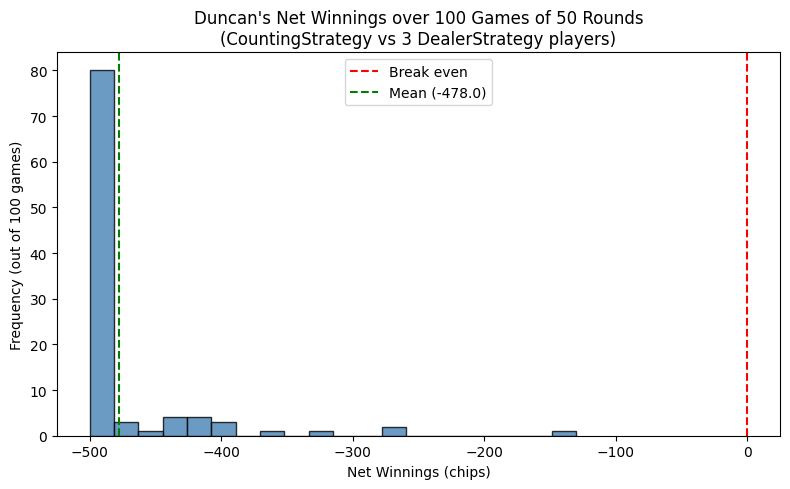

In [17]:
import matplotlib.pyplot as plt
import numpy as np

N_GAMES     = 100
MAX_ROUNDS  = 50
START_CHIPS = 500

winnings = []

for game_num in range(N_GAMES):
    players = [
        Player("Duncan",  chips=START_CHIPS, strategy=CountingStrategy(threshold=0)),
        Player("Player2", chips=START_CHIPS, strategy=DealerStrategy()),
        Player("Player3", chips=START_CHIPS, strategy=DealerStrategy()),
        Player("Player4", chips=START_CHIPS, strategy=DealerStrategy()),
    ]

    game = Game(players=players, num_decks=6)
    duncan = players[0]

    for rnd in range(1, MAX_ROUNDS + 1):
        if duncan.chips <= 0:
            break
        game.run_round(verbose=False)

    winnings.append(duncan.chips - START_CHIPS)

winnings      = np.array(winnings)
avg_per_game  = np.mean(winnings)
avg_per_round = np.mean(winnings) / MAX_ROUNDS
std_dev       = np.std(winnings)
prob_win      = np.mean(winnings > 0)
prob_loss     = np.mean(winnings < 0)
prob_break    = np.mean(winnings == 0)

print(f"  {'─'*40}")
print(f"  Games simulated        : {N_GAMES}")
print(f"  Rounds per game        : {MAX_ROUNDS}")
print(f"  Average net per game   : {avg_per_game:+.2f} chips")
print(f"  Average net per round  : {avg_per_round:+.2f} chips")
print(f"  Std deviation          : {std_dev:.2f} chips")
print(f"  P(net win)             : {prob_win:.1%}")
print(f"  P(net loss)            : {prob_loss:.1%}")
print(f"  P(break even)          : {prob_break:.1%}")
print(f"  {'─'*40}")


plt.figure(figsize=(8, 5))
plt.hist(winnings, bins=20, edgecolor="black", color="steelblue", alpha=0.8)
plt.axvline(0,              color="red",    linestyle="--", linewidth=1.5, label="Break even")
plt.axvline(avg_per_game,   color="green",  linestyle="--", linewidth=1.5, label=f"Mean ({avg_per_game:+.1f})")
plt.xlabel("Net Winnings (chips)")
plt.ylabel("Frequency (out of 100 games)")
plt.title("Duncan's Net Winnings over 100 Games of 50 Rounds\n(CountingStrategy vs 3 DealerStrategy players)")
plt.legend()
plt.tight_layout()
plt.show()

9. Repeat previous questions scanning the value of the threshold. Try at least 5 different threshold values. Can you find an optimal value?

   Threshold   Avg/Game  Avg/Round    Std Dev   P(Win)  P(Loss)
  ────────────────────────────────────────────────────────────
          -4    -149.10      -2.98     148.37    15.0%    84.0%
          -2    -319.60      -6.39     124.79     2.0%    97.0%
           0    -471.40      -9.43      51.26     0.0%   100.0%
           2    -500.00     -10.00       0.00     0.0%   100.0%
           4    -500.00     -10.00       0.00     0.0%   100.0%


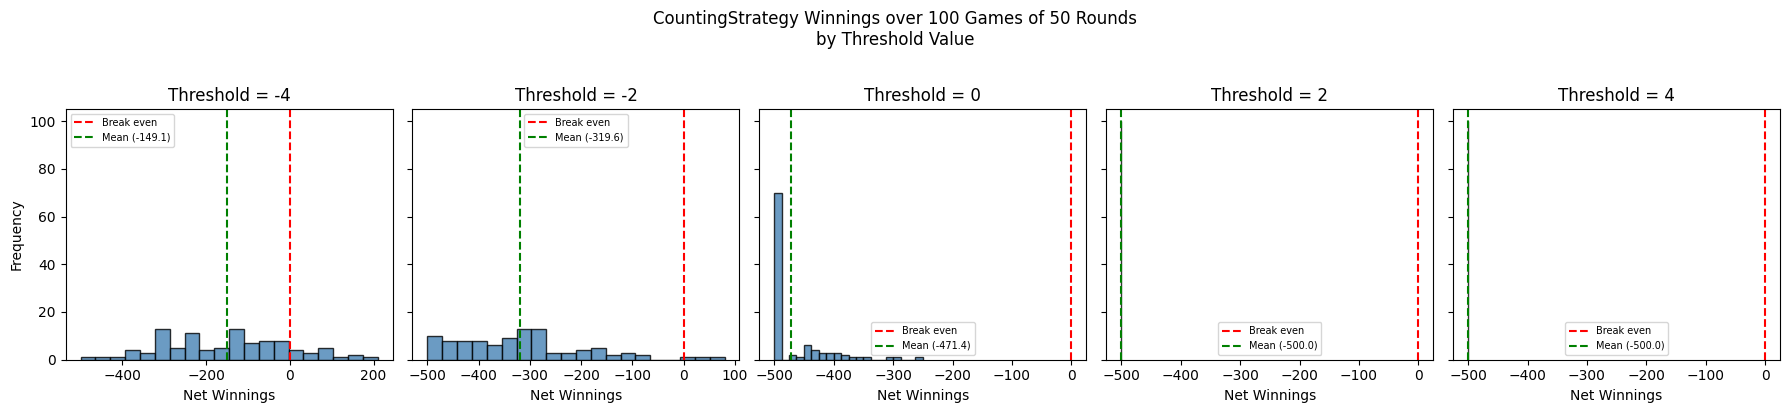


  Best threshold : -4
  Average net    : -149.10 chips per game
        Re-run a few time for optimal value.


In [18]:
import matplotlib.pyplot as plt
import numpy as np


N_GAMES     = 100
MAX_ROUNDS  = 50
START_CHIPS = 500
THRESHOLDS  = [-4, -2, 0, 2, 4]

results = {} 

for threshold in THRESHOLDS:
    winnings = []

    for game_num in range(N_GAMES):
        players = [
            Player("Duncan",  chips=START_CHIPS, strategy=CountingStrategy(threshold=threshold)),
            Player("Player2", chips=START_CHIPS, strategy=DealerStrategy()),
            Player("Player3", chips=START_CHIPS, strategy=DealerStrategy()),
            Player("Player4", chips=START_CHIPS, strategy=DealerStrategy()),
        ]

        game   = Game(players=players, num_decks=6)
        duncan = players[0]

        for rnd in range(1, MAX_ROUNDS + 1):
            if duncan.chips <= 0:
                break
            game.run_round(verbose=False)

        winnings.append(duncan.chips - START_CHIPS)

    results[threshold] = np.array(winnings)

print(f"  {'Threshold':>10} {'Avg/Game':>10} {'Avg/Round':>10} {'Std Dev':>10} {'P(Win)':>8} {'P(Loss)':>8}")
print(f"  {'─'*60}")

for threshold, winnings in results.items():
    avg_game  = np.mean(winnings)
    avg_round = avg_game / MAX_ROUNDS
    std       = np.std(winnings)
    p_win     = np.mean(winnings > 0)
    p_loss    = np.mean(winnings < 0)
    print(f"  {threshold:>10} {avg_game:>+10.2f} {avg_round:>+10.2f} {std:>10.2f} {p_win:>8.1%} {p_loss:>8.1%}")

fig, axes = plt.subplots(1, len(THRESHOLDS), figsize=(18, 4), sharey=True)

for ax, (threshold, winnings) in zip(axes, results.items()):
    avg = np.mean(winnings)
    ax.hist(winnings, bins=20, edgecolor="black", color="steelblue", alpha=0.8)
    ax.axvline(0,   color="red",   linestyle="--", linewidth=1.5, label="Break even")
    ax.axvline(avg, color="green", linestyle="--", linewidth=1.5, label=f"Mean ({avg:+.1f})")
    ax.set_title(f"Threshold = {threshold}")
    ax.set_xlabel("Net Winnings")
    ax.legend(fontsize=7)

axes[0].set_ylabel("Frequency")
fig.suptitle("CountingStrategy Winnings over 100 Games of 50 Rounds\nby Threshold Value", y=1.02)
plt.tight_layout()
plt.show()

best_threshold = max(results, key=lambda t: np.mean(results[t]))
best_avg       = np.mean(results[best_threshold])
sign           = "+" if best_avg >= 0 else ""

print(f"\n  Best threshold : {best_threshold}")
print(f"  Average net    : {sign}{best_avg:.2f} chips per game")
print(f"        Re-run a few time for optimal value.")

10. Create a new strategy based on web searches or your own ideas. Demonstrate that the new strategy will result in increased or decreased winnings. 


  Strategy               Avg/Game  Avg/Round    Std Dev   P(Win)  P(Loss)
  ──────────────────────────────────────────────────────────────────────
  CountingStrategy        -476.80      -9.54      55.24     0.0%   100.0%
  DealerStrategy           -24.05      -0.48      65.57    42.0%    56.0%
  BasicStrategy             -6.00      -0.12     148.73    45.0%    54.0%
  AdaptiveStrategy         -43.25      -0.86     559.97    40.0%    60.0%


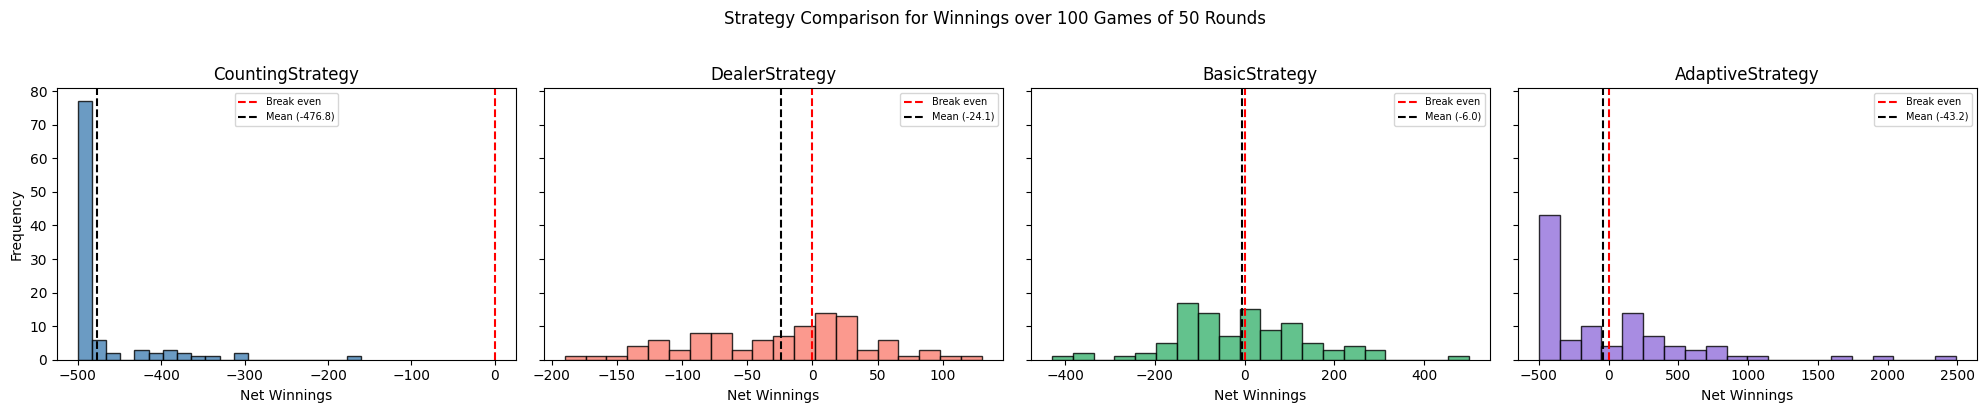


  Best performing strategy: BasicStrategy
  Average net winnings    : -6.00 chips per game


In [20]:
class AdaptiveStrategy(Strategy):
    def __init__(self, min_bet=10, mid_bet=50, max_bet=200):
        self.min_bet = min_bet
        self.mid_bet = mid_bet
        self.max_bet = max_bet

    def place_bet(self, player, decks_remaining: float) -> int:
        tc = player.running_count / max(decks_remaining, 0.5)
        if tc <= 0:
            bet = self.min_bet
        elif tc <= 2:
            bet = self.mid_bet
        else:
            bet = self.max_bet
        return min(bet, player.chips)

    def decide(self, hand, dealer_up_card, decks_remaining: float):
        total      = hand.total
        dealer_val = dealer_up_card.value
        is_soft    = hand.is_soft
        tc         = hand.running_count / max(decks_remaining, 0.5)

        if tc >= 3:
            if total >= 15:
                return Action.STAND
            if total >= 12 and dealer_val in [2, 3, 4, 5, 6]:
                return Action.STAND

        if is_soft:
            if total >= 19:
                return Action.STAND
            if total == 18 and dealer_val in [2, 7, 8]:
                return Action.STAND
            return Action.HIT

        if total >= 17:
            return Action.STAND
        if total >= 13 and dealer_val in [2, 3, 4, 5, 6]:
            return Action.STAND
        if total == 12 and dealer_val in [4, 5, 6]:
            return Action.STAND
        if total == 11:
            return Action.DOUBLE if dealer_val <= 10 else Action.HIT
        if total == 10:
            return Action.DOUBLE if dealer_val <= 9 else Action.HIT
        if total == 9 and dealer_val in [3, 4, 5, 6]:
            return Action.DOUBLE
        return Action.HIT

N_GAMES     = 100
MAX_ROUNDS  = 50
START_CHIPS = 500

strategies = {
    "CountingStrategy": CountingStrategy(threshold=0),
    "DealerStrategy":   DealerStrategy(),
    "BasicStrategy":    BasicStrategy(),
    "AdaptiveStrategy": AdaptiveStrategy(min_bet=10, mid_bet=50, max_bet=200),
}

all_winnings = {}

for strat_name, strat in strategies.items():
    winnings = []

    for game_num in range(N_GAMES):
        players = [
            Player("Focus",   chips=START_CHIPS, strategy=strat.__class__(**strat.__dict__)),
            Player("Player2", chips=START_CHIPS, strategy=DealerStrategy()),
            Player("Player3", chips=START_CHIPS, strategy=DealerStrategy()),
            Player("Player4", chips=START_CHIPS, strategy=DealerStrategy()),
        ]

        game  = Game(players=players, num_decks=6)
        focus = players[0]

        for rnd in range(1, MAX_ROUNDS + 1):
            if focus.chips <= 0:
                break
            game.run_round(verbose=False)

        winnings.append(focus.chips - START_CHIPS)

    all_winnings[strat_name] = np.array(winnings)

print(f"\n  {'Strategy':<20} {'Avg/Game':>10} {'Avg/Round':>10} {'Std Dev':>10} {'P(Win)':>8} {'P(Loss)':>8}")
print(f"  {'─'*70}")

for strat_name, winnings in all_winnings.items():
    avg_game  = np.mean(winnings)
    avg_round = avg_game / MAX_ROUNDS
    std       = np.std(winnings)
    p_win     = np.mean(winnings > 0)
    p_loss    = np.mean(winnings < 0)
    print(f"  {strat_name:<20} {avg_game:>+10.2f} {avg_round:>+10.2f} "
          f"{std:>10.2f} {p_win:>8.1%} {p_loss:>8.1%}")

fig, axes = plt.subplots(1, len(strategies), figsize=(20, 4), sharey=True)

colors = ["steelblue", "salmon", "mediumseagreen", "mediumpurple"]

for ax, (strat_name, winnings), color in zip(axes, all_winnings.items(), colors):
    avg = np.mean(winnings)
    ax.hist(winnings, bins=20, edgecolor="black", color=color, alpha=0.8)
    ax.axvline(0,   color="red",   linestyle="--", linewidth=1.5, label="Break even")
    ax.axvline(avg, color="black", linestyle="--", linewidth=1.5, label=f"Mean ({avg:+.1f})")
    ax.set_title(strat_name)
    ax.set_xlabel("Net Winnings")
    ax.legend(fontsize=7)

axes[0].set_ylabel("Frequency")
fig.suptitle("Strategy Comparison for Winnings over 100 Games of 50 Rounds", y=1.02)
plt.tight_layout()
plt.show()

best = max(all_winnings, key=lambda k: np.mean(all_winnings[k]))
print(f"\n  Best performing strategy: {best}")
print(f"  Average net winnings    : {np.mean(all_winnings[best]):+.2f} chips per game")